## Generate 3 types of curves

Don't forget to **zscore** all values in all curves

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def generate_three_classes_of_signals(num_signals_per_class, signal_length):
    """
    Generates a dataset of 1-D signals with three distinct classes.

    Args:
        num_signals_per_class (int): The number of signals to generate for each class.
        signal_length (int): The number of data points in each signal.

    Returns:
        tuple: A tuple containing:
            - np.ndarray: The generated signals with shape (N, signal_length, 1).
            - np.ndarray: The corresponding class labels with shape (N,).
    """
    signals = []
    labels = []
    x = np.linspace(0, 2 * np.pi, signal_length)

    # --- Class 0: Sine Waves ---
    for _ in range(num_signals_per_class):
        freq = np.random.uniform(1.0, 5.0)  # Frequency between 1 and 5 Hz
        amp = np.random.uniform(0.5, 1.5)  # Amplitude between 0.5 and 1.5
        phase = np.random.uniform(0, 2 * np.pi)  # Phase between 0 and 2*pi
        signal = amp * np.sin(freq * x + phase)  # Sine wave equation
        signals.append(signal)
        labels.append(0)

    # --- Class 1: Normal Distribution with shifting ---
    for _ in range(num_signals_per_class):
        mean = np.random.uniform(-1.0, 1.0)  # Mean of the Gaussian distribution
        std_dev = np.random.uniform(0.1, 0.2)  # Standard deviation for noise
        shift = np.random.uniform(-2.0, 2.0)  # Left/Right shifting
        signal = np.random.normal(mean, std_dev, signal_length)  # Noisy normal signal
        signal = np.roll(signal, int(shift))  # Apply the shift
        signals.append(signal)
        labels.append(1)

    # --- Class 2: Noisy but Very Flat Curves ---
    for _ in range(num_signals_per_class):
        baseline = np.random.uniform(0.0, 0.1)  # Base value of the flat signal
        noise_level = np.random.uniform(0.01, 0.02)  # Small noise level
        signal = np.ones(signal_length) * baseline  # Start with a flat line
        signal += np.random.normal(0, noise_level, signal_length)  # Add small random noise
        signals.append(signal)
        labels.append(2)

    # Convert to NumPy arrays and expand dimensions for the model
    signals = np.array(signals).astype("float32")

    signals = (signals - np.mean(signals)) / np.std(signals)  ### Zscore all curves

    signals = np.expand_dims(signals, axis=-1)  # Expand to shape (N, signal_length, 1)
    labels = np.array(labels)

    return signals, labels


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
#np.random.seed(42)
#tf.random.set_seed(42)

In [4]:
SIGNAL_LENGTH = 128
LATENT_DIM = 64
NUM_SAMPLES = 50
# --- Generate and Visualize the Data ---
signals, labels = generate_three_classes_of_signals(NUM_SAMPLES, SIGNAL_LENGTH)
SIGNAL_LENGTH = signals.shape[1]
NUM_SAMPLES = signals.shape[0]

print(f"Generated signals shape: {signals.shape}")
print(f"Generated # of signals: {NUM_SAMPLES}")
print(f"Generated signals length: {SIGNAL_LENGTH}")
print(f"Generated labels shape: {labels.shape}")

# Create a dictionary to hold signals by class for easy plotting
signal_classes = {
    0: signals[labels == 0],
    1: signals[labels == 1],
    2: signals[labels == 2],
}

Generated signals shape: (150, 128, 1)
Generated # of signals: 150
Generated signals length: 128
Generated labels shape: (150,)


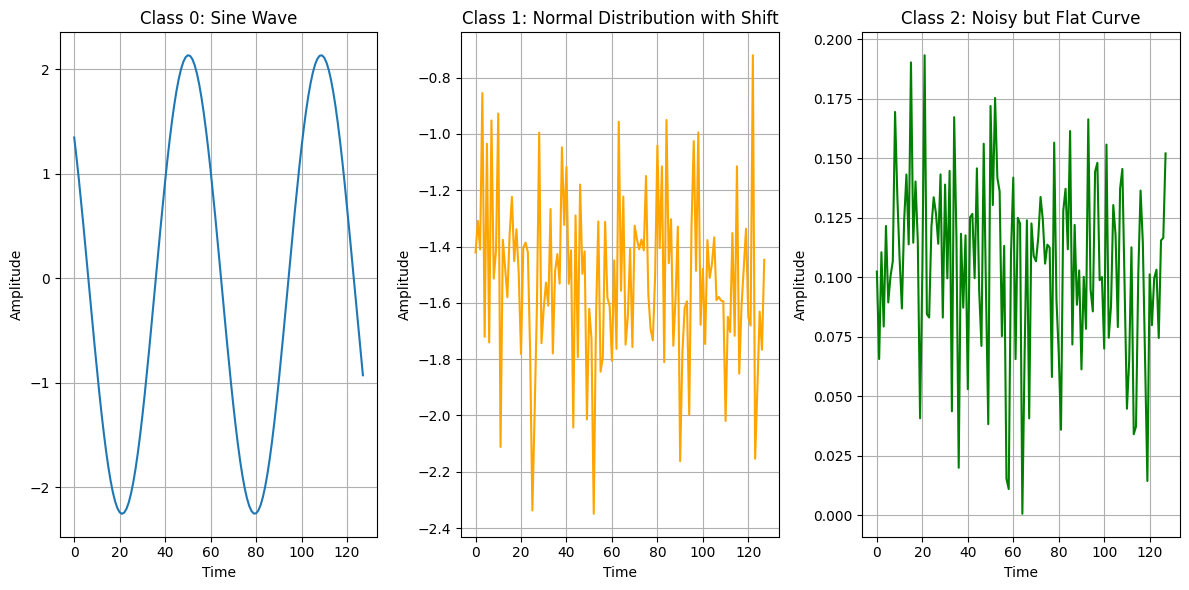

In [5]:
# Plot some examples of each class
plt.figure(figsize=(12, 6))

# Sine wave (Class 0)
plt.subplot(1, 3, 1)
plt.plot(signal_classes[0][0].flatten(), label="Sine Wave")
#plt.ylim(-1, 1)
plt.title("Class 0: Sine Wave")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

# Normal Distribution with shifting (Class 1)
plt.subplot(1, 3, 2)
plt.plot(signal_classes[1][0].flatten(), label="Normal Distribution with Shift", color='orange')
#plt.ylim(-1, 1)
plt.title("Class 1: Normal Distribution with Shift")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

# Noisy but Flat (Class 2)
plt.subplot(1, 3, 3)
plt.plot(signal_classes[2][0].flatten(), label="Noisy Flat Curve", color='green')
#plt.ylim(-1, 1)
plt.title("Class 2: Noisy but Flat Curve")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
''''
# --- Hyperparameters ---
SIGNAL_LENGTH = 128
LATENT_DIM = 32
NUM_SAMPLES = 300

# --- Generate Synthetic 1-D Signals ---
def generate_signals(n_samples, signal_length):
    signals = []
    for _ in range(n_samples):
        # Create a sinusoidal signal with a random frequency and phase
        freq = np.random.uniform(0.05, 0.2)
        phase = np.random.uniform(0, 2 * np.pi)
        x = np.linspace(0, 20, signal_length)
        y = np.sin(freq * x + phase)
        signals.append(y)
    return np.array(signals, dtype=np.float32)

signals = generate_signals(NUM_SAMPLES, SIGNAL_LENGTH)

SIGNAL_LENGTH = signals.shape[1]
NUM_SAMPLES = signals.shape[0]

print(f"Generated signals shape: {signals.shape}")
print(f"Generated # of signals: {NUM_SAMPLES}")
print(f"Generated signals length: {SIGNAL_LENGTH}")
print(f"Generated labels shape: {labels.shape}")
''''

Generated signals shape: (150, 128, 1)
Generated # of signals: 150
Generated signals length: 128
Generated labels shape: (150,)


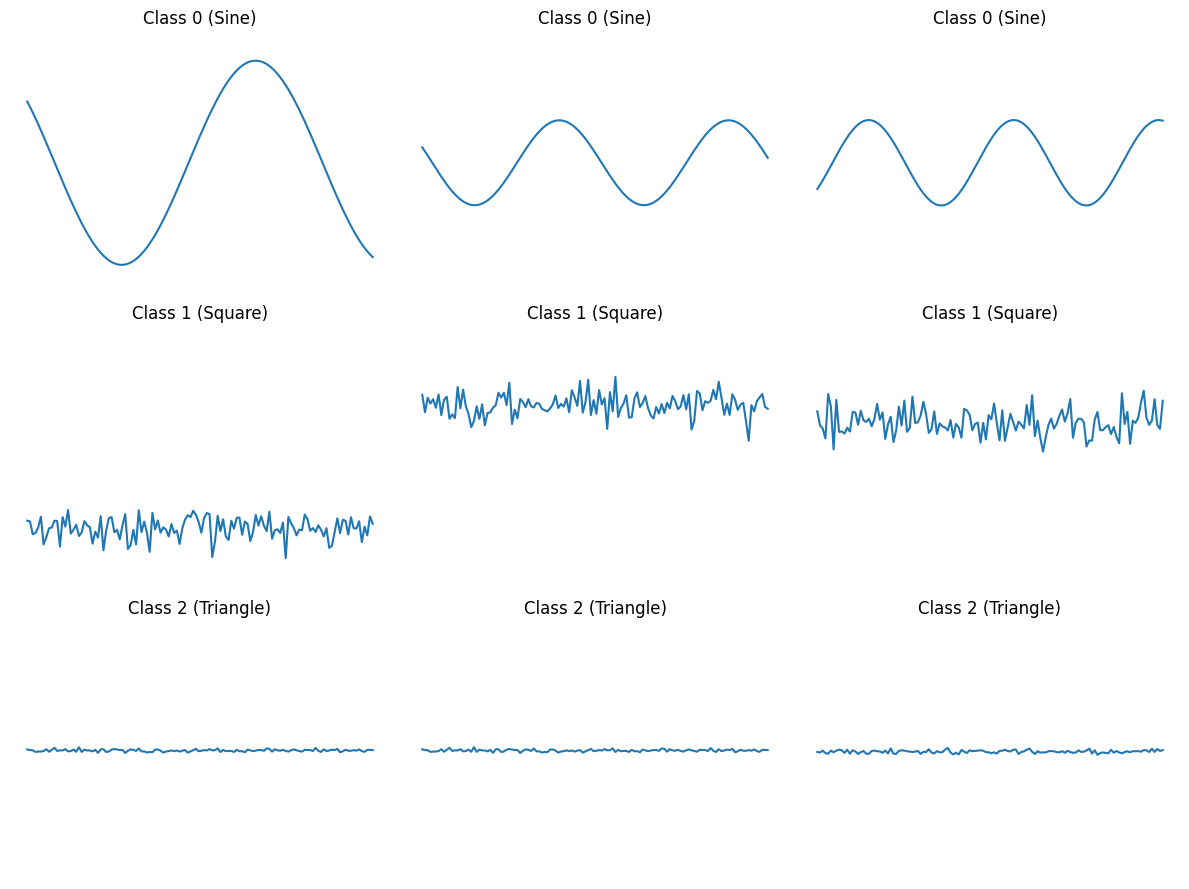

In [6]:
SIGNAL_LENGTH = signals.shape[1]
NUM_SAMPLES = signals.shape[0]

print(f"Generated signals shape: {signals.shape}")
print(f"Generated # of signals: {NUM_SAMPLES}")
print(f"Generated signals length: {SIGNAL_LENGTH}")
print(f"Generated labels shape: {labels.shape}")

# Plot a few examples from each class
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 9))
class_names = ["Sine", "Square", "Triangle"]

for i, (class_label, class_signals) in enumerate(signal_classes.items()):
    for j in range(3):
        ax = axes[i, j]
        # Choose a random signal from the current class
        signal_idx = np.random.randint(0, class_signals.shape[0])
        ax.plot(class_signals[signal_idx])
        ax.set_title(f"Class {class_label} ({class_names[class_label]})")
        ax.set_ylim(-3, 3)
        ax.axis("off")

plt.tight_layout()
plt.show()


# **Build VAE.**
## **Pay attention to how to compute KL_Loss and the final total loss in the "train_step()" function.**
**Chage "beta" will affect training and final generation.**

In [7]:
# --- VAE components ---
from tensorflow.keras.losses import MeanSquaredError

# The Sampling layer for the reparameterization trick
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# VAE Model Class
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss (MSE)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    #keras.losses.mean_squared_error(data, reconstruction)
                    MeanSquaredError()(data, reconstruction)
                )
            )

            # KL Divergence loss
            '''
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            '''
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)

            beta = 1
            total_loss = reconstruction_loss + (beta * kl_loss)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [8]:
# --- Build the VAE ---
LATENT_DIM = 64
BATCH_SIZE = 64
EPOCHS = 300

# Encoder
encoder_inputs = keras.Input(shape=(SIGNAL_LENGTH,))
x = layers.Dense(100, activation="relu")(encoder_inputs)
x = layers.Dense(85, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(85, activation="relu")(latent_inputs)
x = layers.Dense(100, activation="relu")(x)
decoder_outputs = layers.Dense(SIGNAL_LENGTH)(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

# Instantiate and Compile the VAE
vae = VAE(encoder, decoder)
adam_optimizer = keras.optimizers.Adam(learning_rate=1e-4)
vae.compile(optimizer=adam_optimizer)

### **Change "beta" in the loss computing will change the following training losses a lot.**

In [9]:
# --- Train the VAE ---
vae.fit(signals, epochs=EPOCHS, batch_size=BATCH_SIZE)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - kl_loss: 0.2251 - loss: 1.4930 - reconstruction_loss: 1.2508
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 0.2053 - loss: 1.4452 - reconstruction_loss: 1.2170
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 0.1972 - loss: 1.4623 - reconstruction_loss: 1.2433
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 0.1671 - loss: 1.2934 - reconstruction_loss: 1.1647
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 0.1714 - loss: 1.3859 - reconstruction_loss: 1.2170
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 0.1542 - loss: 1.3093 - reconstruction_loss: 1.1801
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 0.1481 - loss: 1.3043 - reconstruction_loss: 1.1363
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 0.1323 - loss: 1.2662 - reconstruction_loss: 1.1559
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - kl_loss: 0.1347 - loss: 1.2823 - reconstruct

## **After training, generate each type of curves.**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


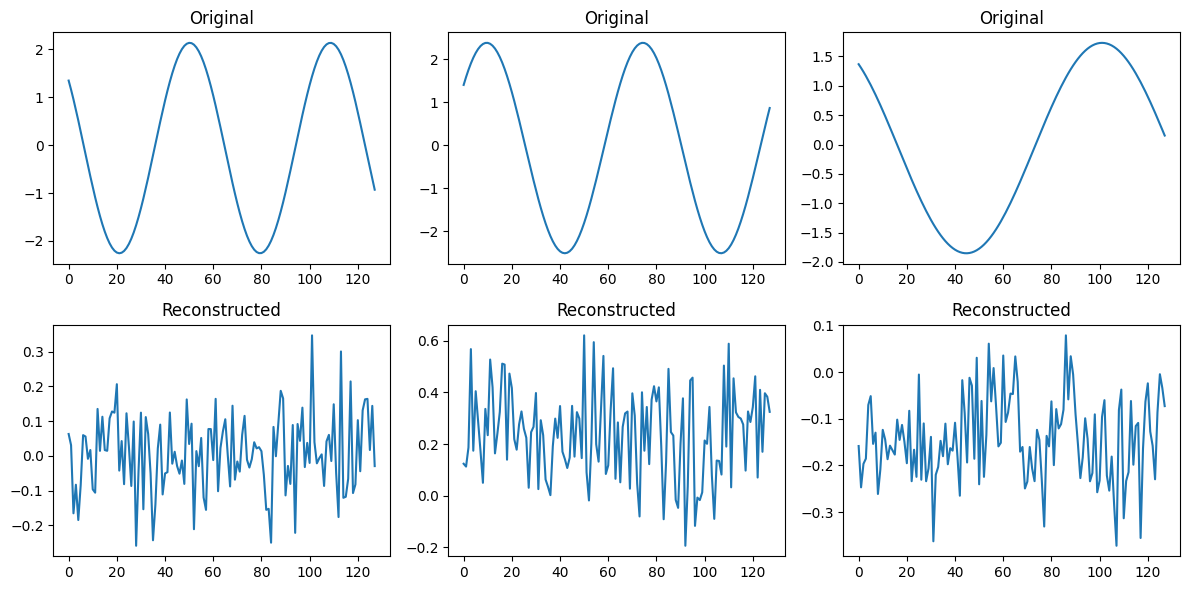

In [10]:
# Assuming 'dataset_signals' is your original numpy array of signals
# And 'vae' is your trained VAE model

# 1. Reconstruct a few signals from the training data
num_to_reconstruct = 3
original_signals = signals[0:3 ]

# Use the encoder to get the latent representation
# The .predict() method on the encoder returns a list of outputs
# In this case, [z_mean, z_log_var, z]
_, _, z = vae.encoder.predict(original_signals)

# Use the decoder to reconstruct the signals from the latent space
reconstructed_signals = vae.decoder.predict(z)

# 2. Plot the original vs. reconstructed signals
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i in range(num_to_reconstruct):
    plt.subplot(2, num_to_reconstruct, i + 1)
    plt.plot(original_signals[i])
    plt.title("Original")
    plt.subplot(2, num_to_reconstruct, i + 1 + num_to_reconstruct)
    plt.plot(reconstructed_signals[i])
    plt.title("Reconstructed")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


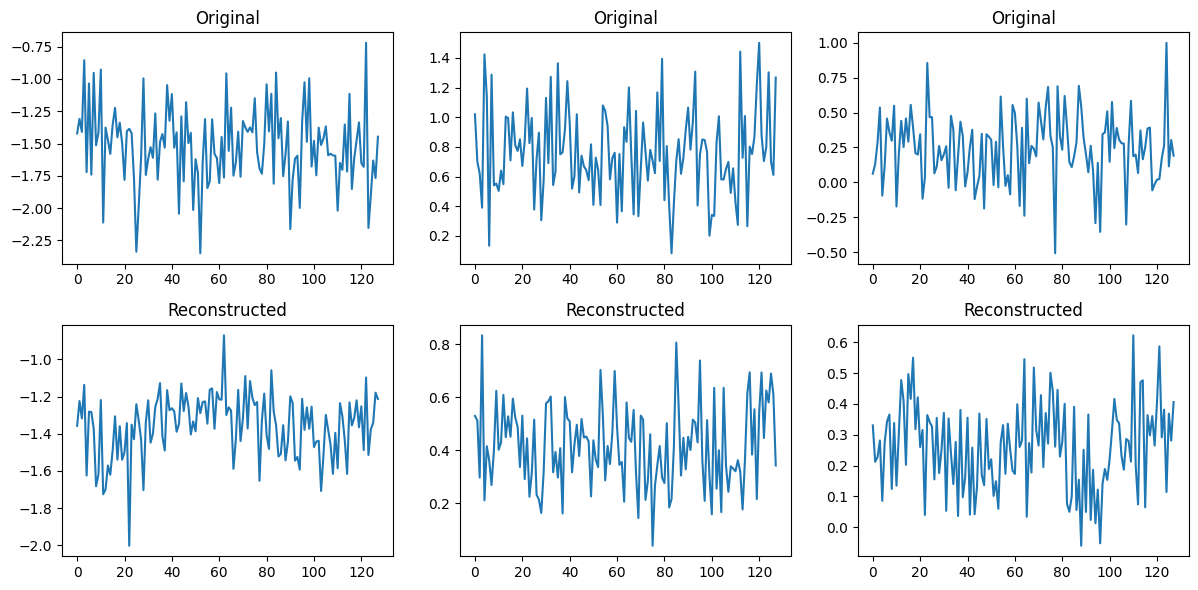

In [11]:
# Assuming 'dataset_signals' is your original numpy array of signals
# And 'vae' is your trained VAE model

# 1. Reconstruct a few signals from the training data
num_to_reconstruct = 3
original_signals = signals[50:53 ]

# Use the encoder to get the latent representation
# The .predict() method on the encoder returns a list of outputs
# In this case, [z_mean, z_log_var, z]
_, _, z = vae.encoder.predict(original_signals)

# Use the decoder to reconstruct the signals from the latent space
reconstructed_signals = vae.decoder.predict(z)

# 2. Plot the original vs. reconstructed signals
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i in range(num_to_reconstruct):
    plt.subplot(2, num_to_reconstruct, i + 1)
    plt.plot(original_signals[i])
    plt.title("Original")
    plt.subplot(2, num_to_reconstruct, i + 1 + num_to_reconstruct)
    plt.plot(reconstructed_signals[i])
    plt.title("Reconstructed")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


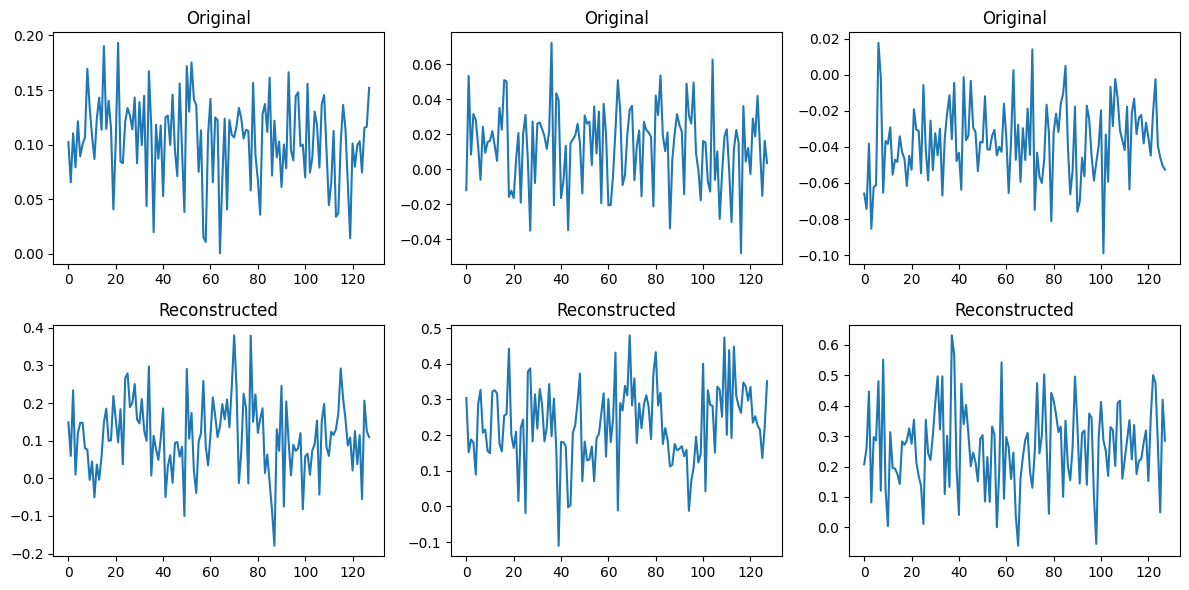

In [12]:
# Assuming 'dataset_signals' is your original numpy array of signals
# And 'vae' is your trained VAE model

# 1. Reconstruct a few signals from the training data
num_to_reconstruct = 3
original_signals = signals[100:103 ]

# Use the encoder to get the latent representation
# The .predict() method on the encoder returns a list of outputs
# In this case, [z_mean, z_log_var, z]
_, _, z = vae.encoder.predict(original_signals)

# Use the decoder to reconstruct the signals from the latent space
reconstructed_signals = vae.decoder.predict(z)

# 2. Plot the original vs. reconstructed signals
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i in range(num_to_reconstruct):
    plt.subplot(2, num_to_reconstruct, i + 1)
    plt.plot(original_signals[i])
    plt.title("Original")
    plt.subplot(2, num_to_reconstruct, i + 1 + num_to_reconstruct)
    plt.plot(reconstructed_signals[i])
    plt.title("Reconstructed")
plt.tight_layout()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


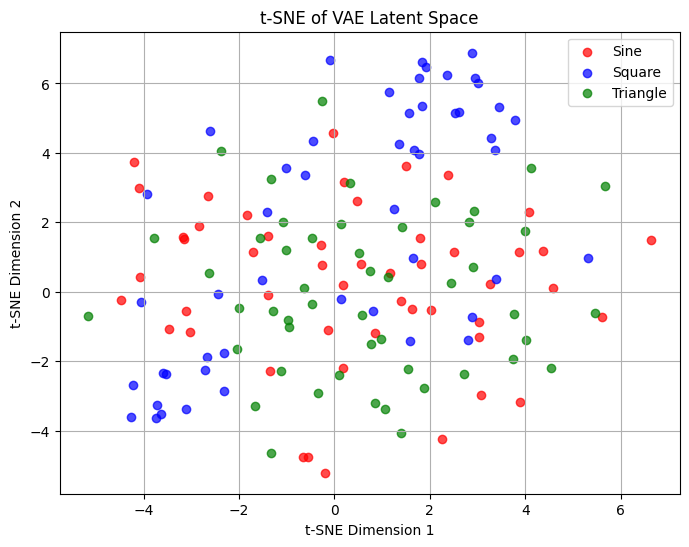

In [13]:
from sklearn.manifold import TSNE

# Use the encoder to get the latent representation
# The .predict() method on the encoder returns a list of outputs
# In this case, [z_mean, z_log_var, z]
_, _, z = vae.encoder.predict(signals)


# Assuming z is (num_samples, latent_dim)
# and labels is (num_samples,)

# Run t-SNE to reduce z to 2 dimensions
tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(z)

# Define class names and colors
class_names = ["Sine", "Square", "Triangle"]
colors = ['red', 'blue', 'green']

# Plot
plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    idx = labels == i
    plt.scatter(z_2d[idx, 0], z_2d[idx, 1],
                c=colors[i], label=class_name, alpha=0.7)

plt.legend()
plt.title("t-SNE of VAE Latent Space")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.show()

# **Example ends here**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


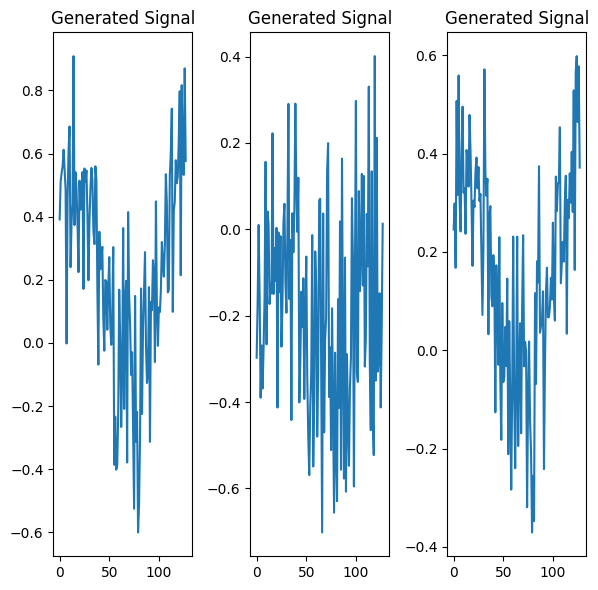

In [ ]:
# Generate new signals from the latent space
def generate_new_signals(latent_dim, num_samples):
    # Sample random points in the latent space
    random_latent_vectors = np.random.normal(size=(num_samples, latent_dim))
    #generated_signals = vae.decoder_mean(vae.decoder_h(random_latent_vectors)).numpy()
    generated_signals = vae.decoder.predict(random_latent_vectors)
    return generated_signals


# Generate new synthetic signals
num_samples = 3
new_signals = generate_new_signals(LATENT_DIM, num_samples)
#print(new_signals)

# Visualize the original and generated signals
plt.figure(figsize=(10, 6))
for i in range(num_samples):
    plt.subplot(1, 5, i + 1)
    plt.plot(new_signals[i])
    plt.title("Generated Signal")
plt.tight_layout()
plt.show()

Generated signals shape: (300, 128, 1)
Generated labels shape: (300,)


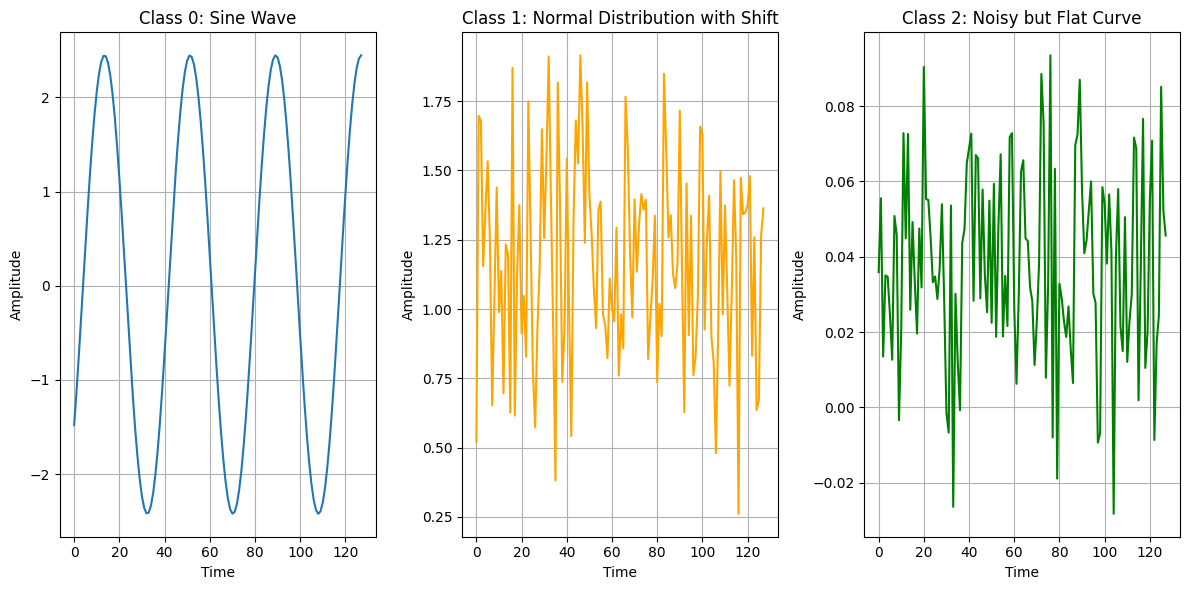

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_three_classes_of_signals(num_signals_per_class, signal_length):
    """
    Generates a dataset of 1-D signals with three distinct classes.

    Args:
        num_signals_per_class (int): The number of signals to generate for each class.
        signal_length (int): The number of data points in each signal.

    Returns:
        tuple: A tuple containing:
            - np.ndarray: The generated signals with shape (N, signal_length, 1).
            - np.ndarray: The corresponding class labels with shape (N,).
    """
    signals = []
    labels = []
    x = np.linspace(0, 2 * np.pi, signal_length)

    # --- Class 0: Sine Waves ---
    for _ in range(num_signals_per_class):
        freq = np.random.uniform(1.0, 5.0)  # Frequency between 1 and 5 Hz
        amp = np.random.uniform(0.5, 1.5)  # Amplitude between 0.5 and 1.5
        phase = np.random.uniform(0, 2 * np.pi)  # Phase between 0 and 2*pi
        signal = amp * np.sin(freq * x + phase)  # Sine wave equation
        signals.append(signal)
        labels.append(0)

    # --- Class 1: Normal Distribution with shifting ---
    for _ in range(num_signals_per_class):
        mean = np.random.uniform(-1.0, 1.0)  # Mean of the Gaussian distribution
        std_dev = np.random.uniform(0.1, 0.2)  # Standard deviation for noise
        shift = np.random.uniform(-2.0, 2.0)  # Left/Right shifting
        signal = np.random.normal(mean, std_dev, signal_length)  # Noisy normal signal
        signal = np.roll(signal, int(shift))  # Apply the shift
        signals.append(signal)
        labels.append(1)

    # --- Class 2: Noisy but Very Flat Curves ---
    for _ in range(num_signals_per_class):
        baseline = np.random.uniform(0.0, 0.1)  # Base value of the flat signal
        noise_level = np.random.uniform(0.01, 0.02)  # Small noise level
        signal = np.ones(signal_length) * baseline  # Start with a flat line
        signal += np.random.normal(0, noise_level, signal_length)  # Add small random noise
        signals.append(signal)
        labels.append(2)

    # Convert to NumPy arrays and expand dimensions for the model
    signals = np.array(signals).astype("float32")
    signals = (signals - np.mean(signals)) / np.std(signals)
    signals = np.expand_dims(signals, axis=-1)  # Expand to shape (N, signal_length, 1)
    labels = np.array(labels)

    return signals, labels


# --- Generate and Visualize the Data ---
signals, labels = generate_three_classes_of_signals(100, 128)

print(f"Generated signals shape: {signals.shape}")
print(f"Generated labels shape: {labels.shape}")

# Create a dictionary to hold signals by class for easy plotting
signal_classes = {
    0: signals[labels == 0],
    1: signals[labels == 1],
    2: signals[labels == 2],
}

# Plot some examples of each class
plt.figure(figsize=(12, 6))

# Sine wave (Class 0)
plt.subplot(1, 3, 1)
plt.plot(signal_classes[0][0].flatten(), label="Sine Wave")
plt.title("Class 0: Sine Wave")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

# Normal Distribution with shifting (Class 1)
plt.subplot(1, 3, 2)
plt.plot(signal_classes[1][0].flatten(), label="Normal Distribution with Shift", color='orange')
plt.title("Class 1: Normal Distribution with Shift")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

# Noisy but Flat (Class 2)
plt.subplot(1, 3, 3)
plt.plot(signal_classes[2][0].flatten(), label="Noisy Flat Curve", color='green')
plt.title("Class 2: Noisy but Flat Curve")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()
